In [1]:
from nmmlab.jansen_rit import nmm1, nmm1_network, k_crit, sigmoid
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#PARAMETERS
tau_x = 0.5
tau_y = 0.5
gx    = 1.0
gy    = 1.0
wxy   = 1.0
wyx   = 1.0
a     = 2.5
Fe    = 0.0
x0    = [0.05, 0, 0.0, 0]

T = 15
t = np.linspace(0, T, 3000)

Kcrit = k_crit(tau_x, tau_y)

# network parameters
N = 3
a_vals = np.array([2.3, 2.5, 2.7])
G = 0.15
C = np.ones((N, N))
np.fill_diagonal(C, 0)
x0_net = np.array([0.05, -0.03, 0.02,  0, 0, 0,  0.0, 0.0, 0.0,  0, 0, 0])
T_net = 20
t_net = np.linspace(0, T_net, 4000)
colors = ['steelblue', 'darkorange', 'green']


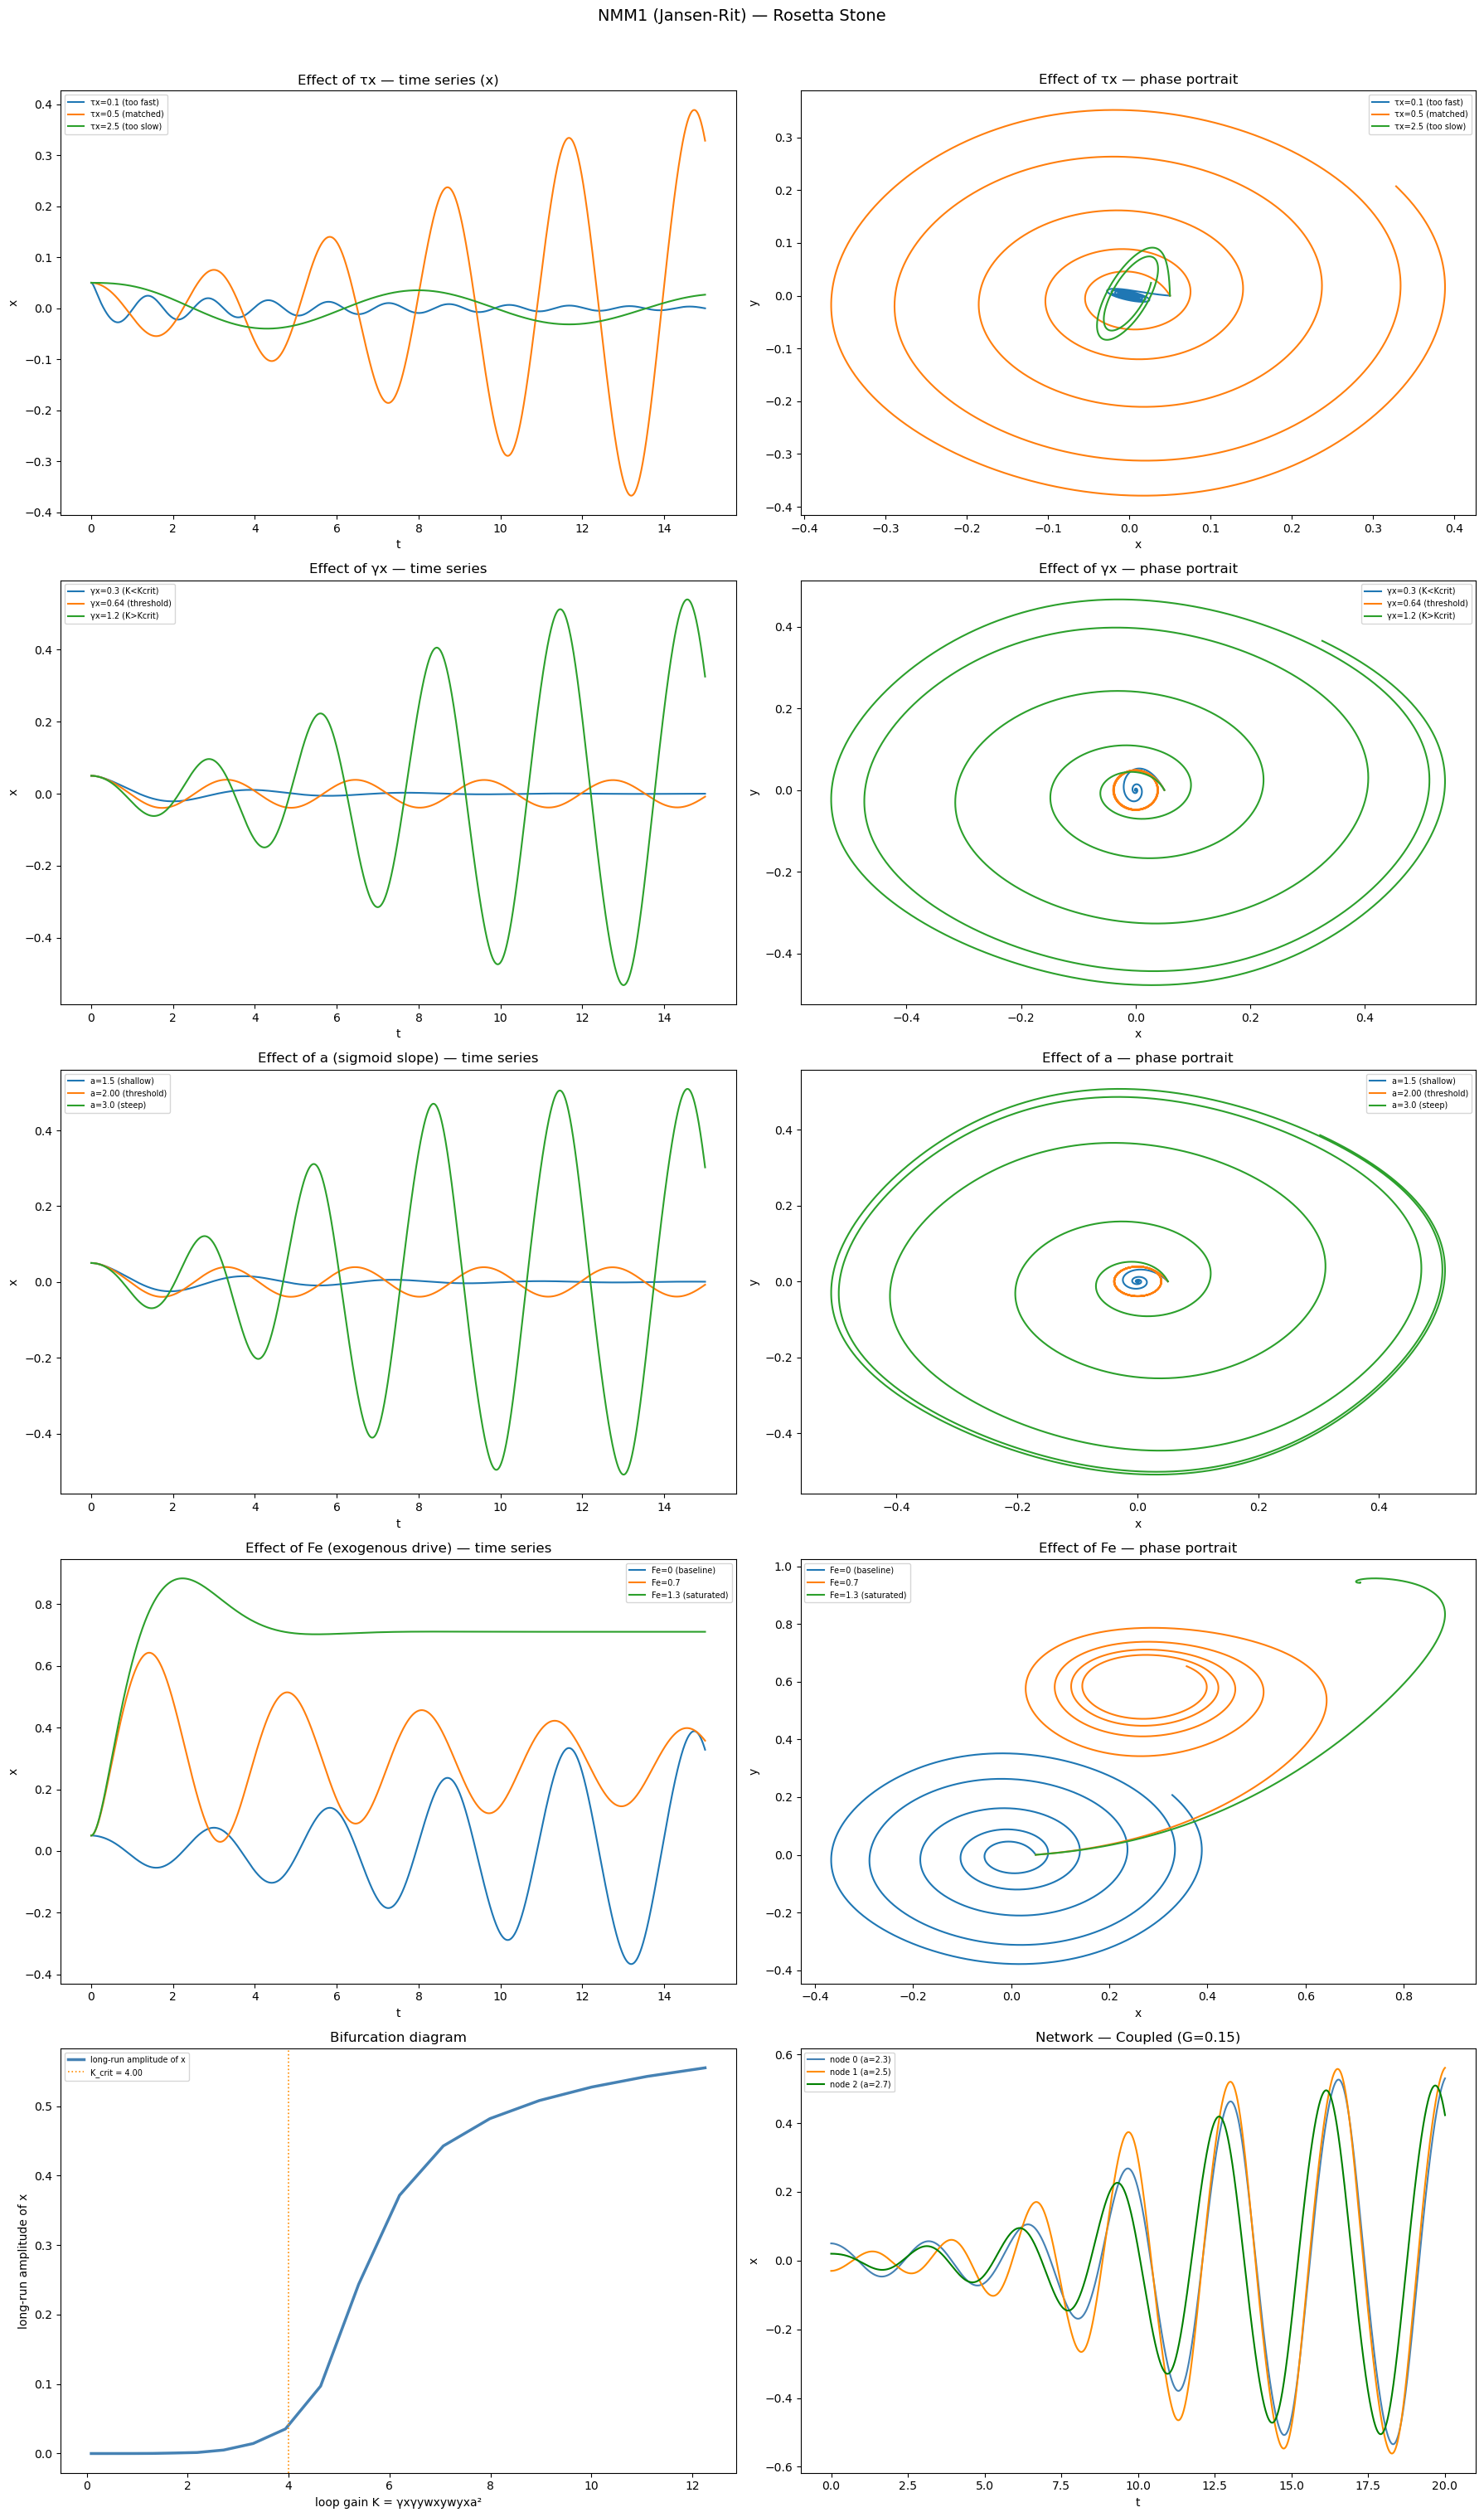

In [3]:
fig = plt.figure(figsize=(18, 30))

# ── Row 1: Effect of τx ──
ax1 = fig.add_subplot(5, 2, 1)
ax2 = fig.add_subplot(5, 2, 2)
for tx, label in zip([0.1, 0.5, 2.5], ['τx=0.1 (too fast)', 'τx=0.5 (matched)', 'τx=2.5 (too slow)']):
    sol = nmm1(tx, tau_y, gx, gy, wxy, wyx, a, Fe, x0, t)
    ax1.plot(t, sol[0], label=label)
    ax2.plot(sol[0], sol[2], label=label)
ax1.set_title("Effect of τx — time series (x)")
ax1.set_xlabel("t"); ax1.set_ylabel("x")
ax2.set_title("Effect of τx — phase portrait")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax1.legend(fontsize=7); ax2.legend(fontsize=7)

# ── Row 2: Effect of γx (loop gain) ──
ax3 = fig.add_subplot(5, 2, 3)
ax4 = fig.add_subplot(5, 2, 4)
gx_crit = Kcrit / (gy * wxy * wyx * a**2)
for g, label in zip([0.3, round(gx_crit, 2), 1.2], [f'γx=0.3 (K<Kcrit)', f'γx={gx_crit:.2f} (threshold)', 'γx=1.2 (K>Kcrit)']):
    sol = nmm1(tau_x, tau_y, g, gy, wxy, wyx, a, Fe, x0, t)
    ax3.plot(t, sol[0], label=label)
    ax4.plot(sol[0], sol[2], label=label)
ax3.set_title("Effect of γx — time series")
ax3.set_xlabel("t"); ax3.set_ylabel("x")
ax4.set_title("Effect of γx — phase portrait")
ax4.set_xlabel("x"); ax4.set_ylabel("y")
ax3.legend(fontsize=7); ax4.legend(fontsize=7)

# ── Row 3: Effect of a (sigmoid slope) ──
ax5 = fig.add_subplot(5, 2, 5)
ax6 = fig.add_subplot(5, 2, 6)
a_crit = np.sqrt(Kcrit / (gx * gy * wxy * wyx))
for av, label in zip([1.5, round(a_crit, 2), 3.0], [f'a=1.5 (shallow)', f'a={a_crit:.2f} (threshold)', 'a=3.0 (steep)']):
    sol = nmm1(tau_x, tau_y, gx, gy, wxy, wyx, av, Fe, x0, t)
    ax5.plot(t, sol[0], label=label)
    ax6.plot(sol[0], sol[2], label=label)
ax5.set_title("Effect of a (sigmoid slope) — time series")
ax5.set_xlabel("t"); ax5.set_ylabel("x")
ax6.set_title("Effect of a — phase portrait")
ax6.set_xlabel("x"); ax6.set_ylabel("y")
ax5.legend(fontsize=7); ax6.legend(fontsize=7)

# ── Row 4: Effect of Fe (exogenous drive) ──
ax7 = fig.add_subplot(5, 2, 7)
ax8 = fig.add_subplot(5, 2, 8)
for F, label in zip([0.0, 0.7, 1.3], ['Fe=0 (baseline)', 'Fe=0.7', 'Fe=1.3 (saturated)']):
    sol = nmm1(tau_x, tau_y, gx, gy, wxy, wyx, a, F, x0, t)
    ax7.plot(t, sol[0], label=label)
    ax8.plot(sol[0], sol[2], label=label)
ax7.set_title("Effect of Fe (exogenous drive) — time series")
ax7.set_xlabel("t"); ax7.set_ylabel("x")
ax8.set_title("Effect of Fe — phase portrait")
ax8.set_xlabel("x"); ax8.set_ylabel("y")
ax7.legend(fontsize=7); ax8.legend(fontsize=7)

# ── Row 5: Bifurcation diagram (loop gain K) + Network ──
ax9 = fig.add_subplot(5, 2, 9)
a_range = np.linspace(0.3, 3.5, 20)
K_range = gx * gy * wxy * wyx * a_range**2
amps = []
for av in a_range:
    sol = nmm1(tau_x, tau_y, gx, gy, wxy, wyx, av, Fe, x0, t)
    tail = sol[0][len(t)*2//3:]
    amps.append((tail.max() - tail.min()) / 2)
ax9.plot(K_range, amps, color='steelblue', lw=2.5, label='long-run amplitude of x')
ax9.axvline(Kcrit, color='darkorange', lw=1.2, ls=':', label=f'K_crit = {Kcrit:.2f}')
ax9.set_title("Bifurcation diagram")
ax9.set_xlabel("loop gain K = γxγywxywyxa²"); ax9.set_ylabel("long-run amplitude of x")
ax9.legend(fontsize=7)

ax10 = fig.add_subplot(5, 2, 10)
sol_net = nmm1_network(tau_x, tau_y, gx, gy, wxy, wyx, a_vals, Fe, G, C, x0_net, t_net)
for i in range(N):
    ax10.plot(t_net, sol_net[i], color=colors[i], label=f'node {i} (a={a_vals[i]})')
ax10.set_title(f"Network — Coupled (G={G})")
ax10.set_xlabel("t"); ax10.set_ylabel("x")
ax10.legend(fontsize=7)

plt.suptitle("NMM1 (Jansen-Rit) — Rosetta Stone", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

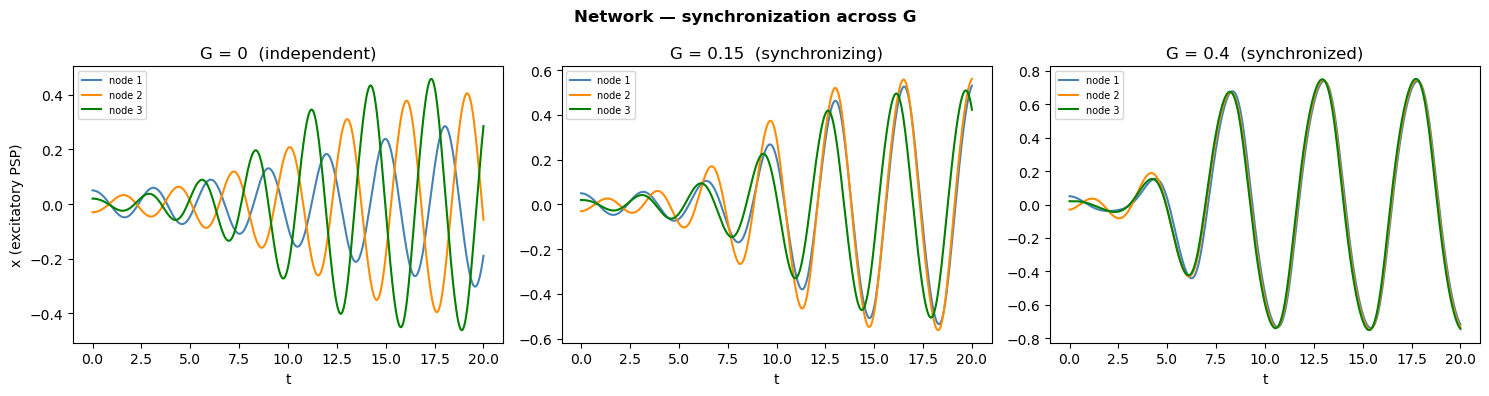

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, G_val, title in zip(axes, [0.0, 0.15, 0.4],
                            ['G = 0  (independent)', 'G = 0.15  (synchronizing)', 'G = 0.4  (synchronized)']):
    sol = nmm1_network(tau_x, tau_y, gx, gy, wxy, wyx, a_vals, Fe, G_val, C, x0_net, t_net)
    for i in range(N):
        ax.plot(t_net, sol[i], color=colors[i], label=f'node {i+1}')
    ax.set_title(title)
    ax.set_xlabel('t')
    ax.legend(fontsize=7)

axes[0].set_ylabel('x (excitatory PSP)')
plt.suptitle('Network — synchronization across G', fontweight='bold')
plt.tight_layout()
plt.show()